# Data Transformations: Skewing and Unskewing

## Learning Objectives
By the end of this notebook, you will understand:
- **Covariance matrices and eigenvectors**: How they describe the shape of data
- **Data transformations**: Why and how we transform data distributions
- **Unskewing techniques**: Methods to normalize skewed data
- **Practical applications**: When transformations improve machine learning performance

## The Big Picture
Data often comes in shapes that don't match our assumptions. This notebook explores:
1. **Understanding data shape** through covariance matrices and eigenvectors
2. **Transforming data** to reveal hidden patterns
3. **When transformations help** in machine learning applications

## Key Concepts
- **Covariance matrix**: Describes how variables vary together
- **Eigenvectors**: The principal directions of variation in the data
- **Unskewing**: Transforming data to have more uniform variance in all directions
- **Whitening**: Making data uncorrelated with unit variance

## Setting Up Our Environment

We'll need several libraries for this analysis:
- **numpy**: For numerical operations and random number generation
- **pandas**: For data manipulation and analysis
- **matplotlib**: For visualization
- **scipy**: For advanced linear algebra operations
- **sklearn**: For machine learning models and preprocessing

**Reproducibility**: Setting random seeds ensures consistent results across runs.

In [ ]:
# Some useful libraries
import numpy as np
from numpy.random import default_rng

# Pandas for data structure and analysis tools
import pandas as pd

# matplotlib for plotting
import matplotlib.pyplot as plt

#for nice vector graphics
%matplotlib inline

#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('png', 'pdf')

np.random.seed(42) # Fixed seed for reproducibility
rng = default_rng(42)

## Understanding Data Shape: The Foundation

Before we can transform data effectively, we need to understand how to describe its shape mathematically. This problem from Lab 1 introduces the key concepts:

**What we'll learn:**
- How to generate data with specific covariance structures
- How to compute empirical covariance from data
- The relationship between covariance matrices and data shape
- How eigenvectors reveal the principal directions of variation

**The key insight**: The eigenvectors of the covariance matrix point in the directions where the data varies most and least.

## Let's star with Lab 1, Problem 5

We go over the optional problem from the lab.
The point of this lab is to understand the relationship between the shape of the data cloud, and the covariance matrix.

### Problem 5 (Optional, recommended)

**Part 1.** Generate 1,000 samples of 2 dimensional data from the Gaussian distribution $\left(\begin{array}{cc}X_{i}\\Y_{i}\end{array}\right)∼N\biggl(\left(\begin{array}{cc}-5\\5\end{array}\right),\left(\begin{array}{cc}2 & 0.8\\0.8 & 3\end{array}\right)\biggr)$.

**Part 2.** Plot these points.

**Part 3.** Find the Eigenvectors and Eigenvalues of the covariance matrix using np.linalg.eig, or np.linalg.eigh, or something else of your choice.

**Part 4.** Now take the 1,000 points you generated in the first part, and use them to estimate the mean and covariance matrix for this multi-dimensional data using elementary numpy commands, i.e., addition, multiplication, division (do not use a command that takes data and returns the mean or standard deviation).

*Remark*: If you did this correctly: You should have made a number of observations. (i) The points you plotted should look like an elongated ellipse. (ii) The axis of elongation (the major axis of the ellipse) should be aligned with the eigenvector you computed that has the largest eigenvalue. The minor axis, should be aligned with the other eigenvector you computed. (iii) In the last part, you computed what is called the *empirical covariance* matrix. This should be quite close to the covariance matrix you used to generate the data. If we used more and more points (10,000, 100,000, etc.), then our empirical estimate would look more and more like what we used to generate the data.


# Solution to Problem 5:

To find the empirical covariance between two random variables, $X$ and $Y$ where we are given $N$ samples $(x_1,y_1), (x_2,y_2), \dots, (x_N,y_N)$, we use the following equation.

$$Cov(X, Y) = \frac{1}{N-1} \sum_{j = 1}^{N}(X_{j}- \mu_{x})*(Y_{j}- \mu_{y}) $$

**A simplification for zero mean data**
Suppose that our data are centered. And, overloading notation for a second suppose that I store the data in a matrix $X$, where the points are written as rows of $X$. Using $x$ and $y$ to map to the above, this would mean we have:
$$
X = \left[ \begin{array}{cc} x_1 & y_1 \\ x_1 & y_1 \\ \vdots & \vdots \\ x_N & y_N \end{array} \right]
$$
Then, note that the covariance matrix of the data calculation above (recall $\mu_x = \mu_y = 0$) becomes, simply:
$$
{\rm Cov} = \frac{1}{N-1}X^{\top}X
$$


### Generating Data with Known Structure

Let's create data with a specific covariance structure to understand the relationship between covariance and data shape:

**What we're doing:**
- Generate 10,000 points from a bivariate normal distribution
- Use a covariance matrix that creates an elongated ellipse
- Visualize how the covariance affects the data shape

**Key parameters:**
- **Mean**: [-5, 5] - centers the data cloud
- **Covariance**: [[2, 1.4], [1.4, 3]] - creates correlation and elongation
- **Sample size**: 10,000 - ensures good empirical estimates

In [ ]:
# Try different values for the covariance.
# For example:
# cov = [[2, 0], [0, 3]]
# cov = [[2, 1.4], [1.4, 3]]
# cov = [[2, 1.9], [1.9, 3]]
# cov = [[2, 2.4], [2.4, 3]]

samples = 10000
mu = [-5, 5]
cov = [[2, 1.4], [1.4, 3]]

# Part 1 Solution
# 1000 samples from bivariate Normal distribution
# with given mu and covariance matrix
x, y = rng.multivariate_normal(mu, cov, samples).T



[]

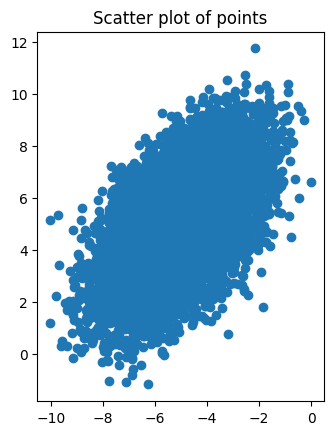

In [ ]:
# Part 2 solution
# We can plot the points to see what they look like
plt.scatter(x, y)
axes = plt.gca()
axes.set_aspect(1) # set aspect ratio to 1 to see the alignment
plt.title('Scatter plot of points')
plt.plot()

In [ ]:
# Part 3 solution
E, V = np.linalg.eigh(cov)
print('These are the eigenvalues:', E)
print('These are the eigenvectors:', V)


These are the eigenvalues: [1.01339313 3.98660687]
These are the eigenvectors: [[-0.81741556  0.57604844]
 [ 0.57604844  0.81741556]]


We just computed the eigenvectors of the covariance matrix.

What is the relationship between the data and the eigenvectors of the covariance??

[]

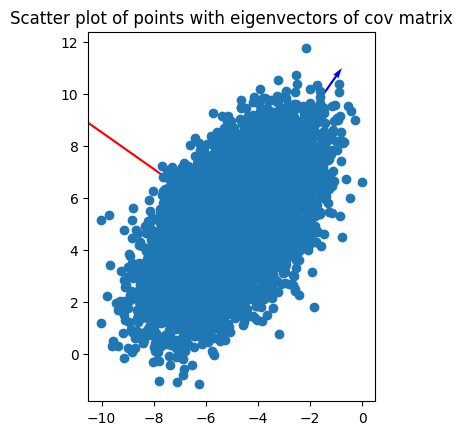

In [ ]:
# We can plot the eigenvectors on the same plot as the points
origin = np.array([[-5, -5],[5, 5]]) # origin point

plt.quiver(*origin, V[:,0], V[:,1], color=['r','b'], scale=1.5)
plt.scatter(x, y)
axes = plt.gca()
axes.set_aspect(1) # set aspect ratio to 1 to see the alignment
plt.title('Scatter plot of points with eigenvectors of cov matrix')

plt.plot()

### Extracting the Principal Directions

The eigenvectors of the covariance matrix reveal the principal directions of variation in the data:

**What eigenvectors tell us:**
- **Direction**: The orientation of the data cloud
- **Magnitude**: How much variation occurs in each direction (eigenvalues)
- **Orthogonality**: The principal directions are perpendicular to each other

### Visualizing the Principal Directions

Plotting the eigenvectors on top of the data reveals the structure:

**What to observe:**
- **Red arrow**: Points in the direction of maximum variance (largest eigenvalue)
- **Blue arrow**: Points in the direction of minimum variance (smallest eigenvalue)
- **Orthogonality**: The arrows are perpendicular to each other
- **Alignment**: The arrows align with the elongation of the data cloud

**The connection**: The eigenvectors are literally the axes of the data ellipse!

In [ ]:
# Part 4 solution

#compute means
meanX = np.sum(x) / samples
meanY = np.sum(y) / samples

mean = [meanX, meanY]

#compute the variance as before and the covariance
#using the equation for computing covariance
varX = np.sum((x - meanX)**2) / (samples - 1.0)
varY = np.sum((y - meanY)**2) / (samples - 1.0)

#compute covariance between x and y, as n increases this should approach 0.8
covXY = np.dot((x - meanX),(y - meanY)) / (samples - 1.0)

covMatrix = np.array([[varX, covXY], [covXY, varY]])

#print out the mean and covariance matrix
print("Mean:\n", mean, "\n")
print("Covariance:\n", covMatrix)

Mean:
 [np.float64(-5.007645515330857), np.float64(5.01036599809946)] 

Covariance:
 [[2.0330063  1.36621586]
 [1.36621586 2.94150526]]


# Two sentence summary

1. We learned how to plot data with a given covariance and how to compute the covariance of data.
2. We learned that the eigenvectors of the covariance matrix are the axes of the cloud of data.

### Let's apply some of these ideas

## Why do we need to transform data?

Now we move from understanding data shape to transforming it:

**Why unskew data?**
1. **Reveal hidden patterns**: Skewed data can obscure underlying structure
2. **Improve model performance**: Some algorithms work better with normalized data
3. **Better outlier detection**: Transformed data can reveal true outliers
4. **Statistical assumptions**: Many methods assume roughly spherical data

**Important caveat**: We're not throwing away information - we're revealing it in a different form!

### Simple Case: Diagonal Covariance Matrix

Let's start with the simplest case - a diagonal covariance matrix:

**The setup:**
- **Mean**: [0, 0] - centered at origin
- **Covariance**: [[16, 0], [0, 1]] - no correlation, different variances
- **Result**: An elongated ellipse aligned with the coordinate axes

**What we'll do:**
1. Generate the skewed data
2. Find the eigenvectors (trivial in this case)
3. Apply the unskewing transformation
4. Verify the result is spherical

[]

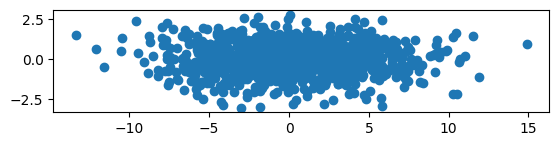

In [ ]:
#1000 samples from bivariate Normal distribution
#with given mu and covariance matrix

rng = default_rng(38)
samples = 1000
mu = [0, 0] # Mean at the origin (0,0)
cov = [[16, 0], [0, 1]] # covariance matrix
X = rng.multivariate_normal(mu, cov, samples) # generate the points

# We can plot the points to see what they look like
origin = np.array([[0, 0],[0, 0]]) # origin point
plt.scatter(X[:,0], X[:,1])
axes = plt.gca()
axes.set_aspect(1) # set aspect ratio to 1 to see the alignment
plt.plot()

**Directions of elongation?**

[]

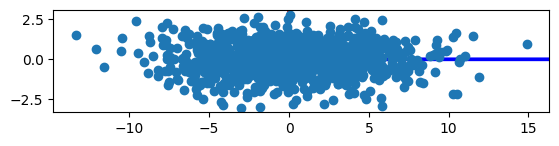

In [ ]:
# We need to compute the eigenvectors of the data
L, V = np.linalg.eigh(cov) # get the eigenvectors of the covariance matrix
#Vs = np.dot(V,np.diag(L)).T # scale by the eigenvalues
plt.quiver(*origin, V[:,0], V[:,1], color=['r','b'], scale=1.5)
plt.scatter(X[:,0], X[:,1])
axes = plt.gca()
axes.set_aspect(1) # set aspect ratio to 1 to see the alignment
plt.plot()

In [ ]:
# print the eigenvectors
print(V)

[[0. 1.]
 [1. 0.]]


**We need to rescale in these two directions**

1. By how much?
2. How do we do this?



**Eigenvalues**

The eigenvalues tell us how much

In [ ]:
print(L)

[ 1. 16.]


**Hence**

We need to rescale by:
1. $1/\sqrt{1} = 1$ in the [0,1] direction
2. $1/\sqrt{16} = 1/4$ in the [1,0] direction.

In [ ]:
# Make rescaling matrix
R = np.array([[1/np.sqrt(16), 0], [0, 1/np.sqrt(1)]])

# Multiply the data matrix X by R
X_rescaled = np.dot(X, R)

[]

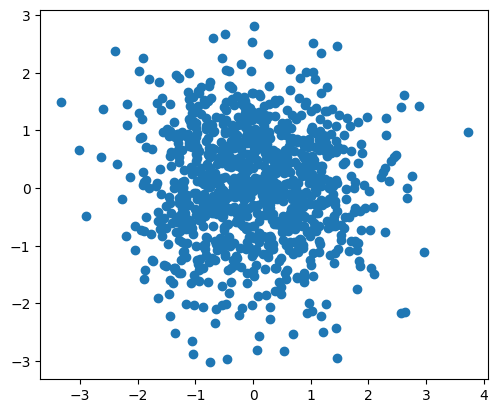

In [ ]:
# Plot the rescaled data
plt.scatter(X_rescaled[:,0], X_rescaled[:,1])
axes = plt.gca()
axes.set_aspect(1) # set aspect ratio to 1 to see the alignment
plt.plot()

**Why did this work?**

Let's use the relationship noted above: if the data are zero-mean (they are, here) and we put our data into a data matrix $X$ as **rows**, then:

1. The data, $X$, have covariance matrix $C_X$ (and mean 0).
2. This covariance matrix is computed by:
$$
C_X = \frac{1}{n-1} X^{\top}X
$$
3. Let $Z = XR$. The covariance matrix of $Z$ is:
$$
C_Z = \frac{1}{n-1} Z^{\top}Z = \frac{1}{n-1} R^{\top}X^{\top}XR = R^{\top}C_X R.
$$
Now let's put in the numbers:
$$
C_Z = \left[ \begin{array}{cc} 1/4 & 0 \\ 0 & 1 \end{array} \right] \cdot \left[ \begin{array}{cc} 16 & 0 \\ 0 & 1 \end{array} \right] \cdot \left[ \begin{array}{cc} 1/4 & 0 \\ 0 & 1 \end{array} \right] = \left[ \begin{array}{cc} 1 & 0 \\ 0 & 1 \end{array} \right]
$$

### General Case: Correlated Data

Now let's tackle the more realistic case where variables are correlated: **Same problem, more interesting/complicated**

**The challenge**:
- **Covariance**: [[1, 0.9], [0.9, 1]] - strong correlation
- **Result**: Ellipse tilted at 45 degrees
- **Solution**: Need to rotate AND rescale

**The general formula**:
$$R = (C_X^{1/2})^{-1}$$

**What this does**:
1. **Rotates** the data to align with eigenvectors
2. **Rescales** by the inverse square root of eigenvalues
3. **Results** in spherical, uncorrelated data



[]

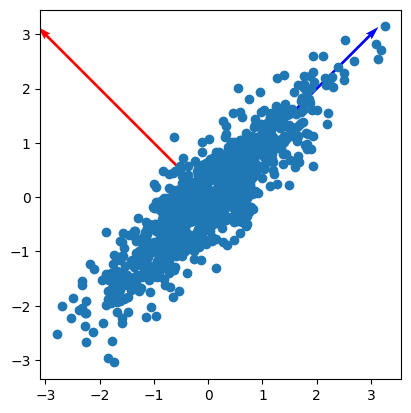

In [ ]:
#1000 samples from bivariate Normal distribution
#with given mu and covariance matrix

samples = 1000
mu = [0, 0] # Mean at the origin (0,0)
cov = [[1, 0.9], [0.9, 1]] # covariance matrix
L, V = np.linalg.eigh(cov) # get the eigenvectors of the covariance matrix
#Vs = np.dot(V,np.diag(L)).T # scale by the eigenvalues
X = rng.multivariate_normal(mu, cov, samples) # generate the points

# We can plot the points to see what they look like
origin = np.array([[0, 0],[0, 0]]) # origin point

plt.quiver(*origin, V[:,0], V[:,1], color=['r','b'], scale=1.5)
plt.scatter(X[:,0], X[:,1])
axes = plt.gca()
axes.set_aspect(1) # set aspect ratio to 1 to see the alignment
#axes.set_aspect('equal', 'box')

plt.plot()

**Same procedure**:

The data are skewed in the directions of the two eigenvectors.

To unskew, we need to unskew the space along these two directions, by $1/\sqrt{\lambda_i}$, where $\lambda_i$ represents the $i^{th}$ eigenvalue.

**Fact**: the right matrix $R$ that scales by the above quantities, in the direction of the eigenvectors, is:
$$
R = (C_X^{1/2})^{-1},
$$
i.e., the inverse of the square root of $C_X$.

Note that this is exactly what we used above for the simpler exmaple. Recall we had:
$$
C_X = \left[ \begin{array}{cc} 16 & 0 \\ 0 & 1 \end{array} \right]
$$
and
$$
R = \left[ \begin{array}{cc} 1/4 & 0 \\ 0 & 1 \end{array} \right]
$$

### Implementing the General Transformation

We use scipy's matrix square root and inverse functions:

**The process**:
1. **Compute** $C_X^{1/2}$ (matrix square root)
2. **Invert** to get $(C_X^{1/2})^{-1}$
3. **Apply** the transformation: $Z = XR$

**Verification**: The transformed data should have covariance matrix close to identity.```
import scipy as sp
R = sp.linalg.inv(sp.linalg.sqrtm(cov))
```
Let's try it!

In [ ]:
import scipy as sp
R = sp.linalg.inv(sp.linalg.sqrtm(cov))
X_rescaled = np.dot(X, R)

[]

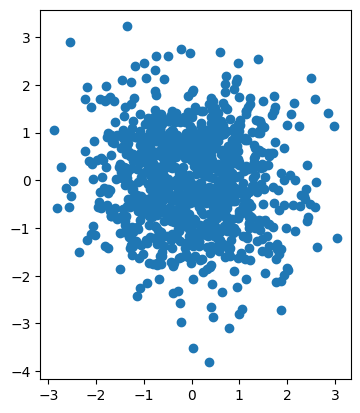

In [ ]:
# Plot the rescaled data
plt.scatter(X_rescaled[:,0], X_rescaled[:,1])
axes = plt.gca()
axes.set_aspect(1) # set aspect ratio to 1 to see the alignment
plt.plot()

**Again: why did this work?**

1. Recall that $C_X = \frac{1}{n-1}X^{\top}X$.
2. Let $Z = XR$. Then:
$$
C_Z = \frac{1}{n-1}Z^{\top}Z = \frac{1}{n}R^{\top}X^{\top}X R = RC_XR.
$$
But
$$
R = \sqrt{C_X}^{-1}
$$
and
$$
C_X = \sqrt{C_X} \sqrt{C_X}
$$
hence:
$$
C_Z = RC_XR = \sqrt{C_X}^{-1} \cdot \sqrt{C_X} \cdot \sqrt{C_X} \cdot \sqrt{C_X}^{-1} = I.
$$

## Practical Applications: When Unskewing Helps

Now let's see how unskewing reveals hidden patterns in real data:

**Example 1**: Clustering in skewed data
- **Problem**: Two clusters hidden by data skew
- **Solution**: Unskew to reveal the true cluster structure

**Example 2**: Outlier detection
- **Problem**: Which points are truly outliers?
- **Solution**: Unskew to see outliers in their true context

**Main point**: The same data can look completely different after transformation!

**Example 1**

Load the data X_aniso.npy, and plot it. You will see that it looks like a single elongated cloud of points.

This file is in Canvas.

In [ ]:
# Upload the train file from your local drive
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# Now load the data
X_aniso = np.load('./X_aniso.npy')

# Let's plot the data
plt.scatter(X_aniso[:, 0], X_aniso[:, 1])

### Example 1: Revealing Hidden Clusters

This dataset appears to be a single elongated cloud. **What should we do?**
As we will see, unskewing reveals its true structure:

**The process**:
1. **Load** the skewed data
2. **Compute** empirical covariance
3. **Apply** unskewing transformation
4. **Discover** hidden clusters

**The revelation**: What looked like one cluster is actually two distinct groups!

**Why this matters**: Clustering algorithms would fail on the original skewed data but succeed on the unskewed data.

In [ ]:
num_samples = X_aniso.shape[0]
x = X_aniso[:,0]
y = X_aniso[:,1]
#compute means
meanX = np.sum(x) / num_samples
meanY = np.sum(y) / num_samples

mean = [meanX, meanY]

#compute the variance as before and the covariance
#using the equation for computing covariance
varX = np.sum((x - meanX)**2) / (num_samples - 1)
varY = np.sum((y - meanY)**2) / (num_samples - 1)

#compute covariance between x and y, as n increases this should approach 0.8
covxy = np.sum((x - meanX)*(y - meanY)) / (num_samples - 1)

covMatrix = np.array([[varX, covxy], [covxy, varY]])

# Note that we could do this in one step using the numpy.cov command:
# covMatrix2 = np.cov(X_aniso,rowvar = False)
# You can uncomment and see these are the same.

# Now we compute the inverse square root
# and use this to multiply the points
S_aniso = sp.linalg.inv(sp.linalg.sqrtm(covMatrix))
X_aniso_unskew = np.dot(S_aniso,X_aniso.T).T


### Now plot

[]

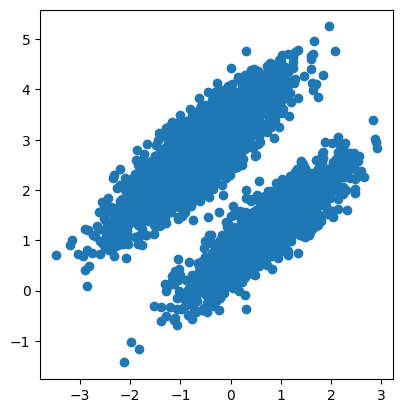

In [ ]:
plt.scatter(X_aniso_unskew[:,0], X_aniso_unskew[:,1])
axes4 = plt.gca()
axes4.set_aspect(1) # set aspect ratio to 1
plt.plot()

We could not see these two clusters in the original data, because the points were so highly skewed.

### Example 2: True Outlier Detection

Load the data in DF2 (this file is in Canvas), and plot it. We can see that this dataset has two apparent outliers.
**Question:** Which one is truly more unusual?

**The challenge**:
- **Visual inspection**: Both points look equally "far out"
- **Reality**: One point is much more unusual in the context of the data structure

**The solution**: Unskew the data to see outliers in their true statistical context

**We learn**: Distance in skewed space ≠ statistical unusualness



In [ ]:
# Upload the train file from your local drive
from google.colab import files
uploaded = files.upload()

Saving DF2 to DF2


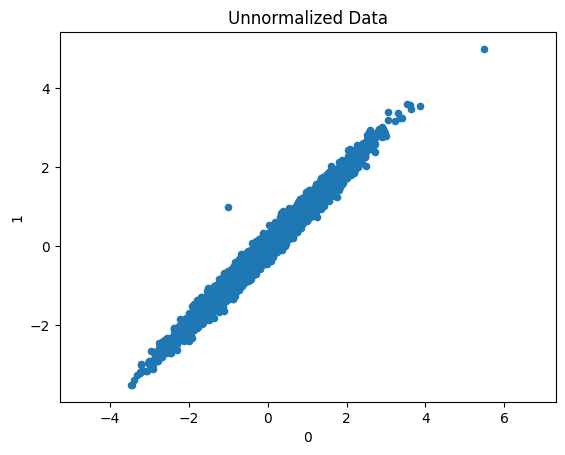

In [ ]:
# Read the data frame and plot it
Z = pd.read_table("./DF2", sep=',', index_col=0)
Z.plot(x=0, y=1, kind="scatter", style="b^")
plt.title('Unnormalized Data')
plt.axis('equal')
plt.show()

**Which point is the most outlying?**

What should we do...?

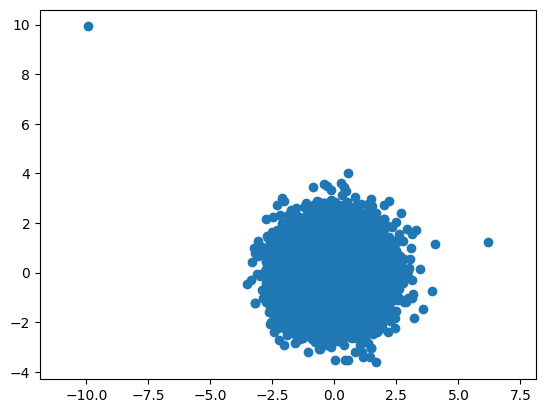

In [ ]:
# We follpow the same procedure.
covZ = np.cov(Z, rowvar=False)
S_Z = sp.linalg.inv(sp.linalg.sqrtm(covZ))
Z_unskew = np.dot(S_Z,Z.T).T
plt.scatter(Z_unskew[:,0], Z_unskew[:,1])
plt.axis('Equal')
plt.show()

## Machine Learning Applications: When Transformations Improve Performance

Unskewing isn't just for visualization - it can significantly improve model performance:

**Example 1**: Regression with skewed targets
- **Problem**: Linear models struggle with exponentially distributed targets
- **Solution**: Log transformation makes the relationship linear

**Example 2**: Classification with skewed features
- **Problem**: Logistic regression assumes roughly normal features
- **Solution**: Power transformations normalize the feature distributions

**The result**: Better model performance and more interpretable results

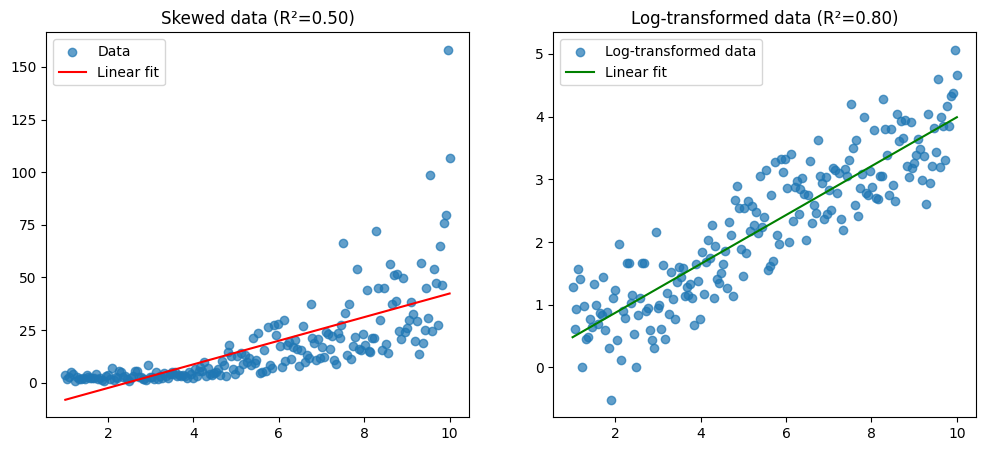

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

# Example 1: Regression with skewed salary-like data
np.random.seed(0)
n = 200
x = np.linspace(1, 10, n)
y = np.exp(0.4 * x + np.random.normal(0, 0.5, n))

# Linear regression without unskewing
model = LinearRegression().fit(x.reshape(-1, 1), y)
y_pred = model.predict(x.reshape(-1, 1))

# Linear regression after log-transforming y
log_y = np.log(y)
model_log = LinearRegression().fit(x.reshape(-1, 1), log_y)
log_y_pred = model_log.predict(x.reshape(-1, 1))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(x, y, alpha=0.7, label='Data')
plt.plot(x, y_pred, color='red', label='Linear fit')
plt.title(f'Skewed data (R²={r2_score(y, y_pred):.2f})')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x, log_y, alpha=0.7, label='Log-transformed data')
plt.plot(x, log_y_pred, color='green', label='Linear fit')
plt.title(f'Log-transformed data (R²={r2_score(log_y, log_y_pred):.2f})')
plt.legend()
plt.show()




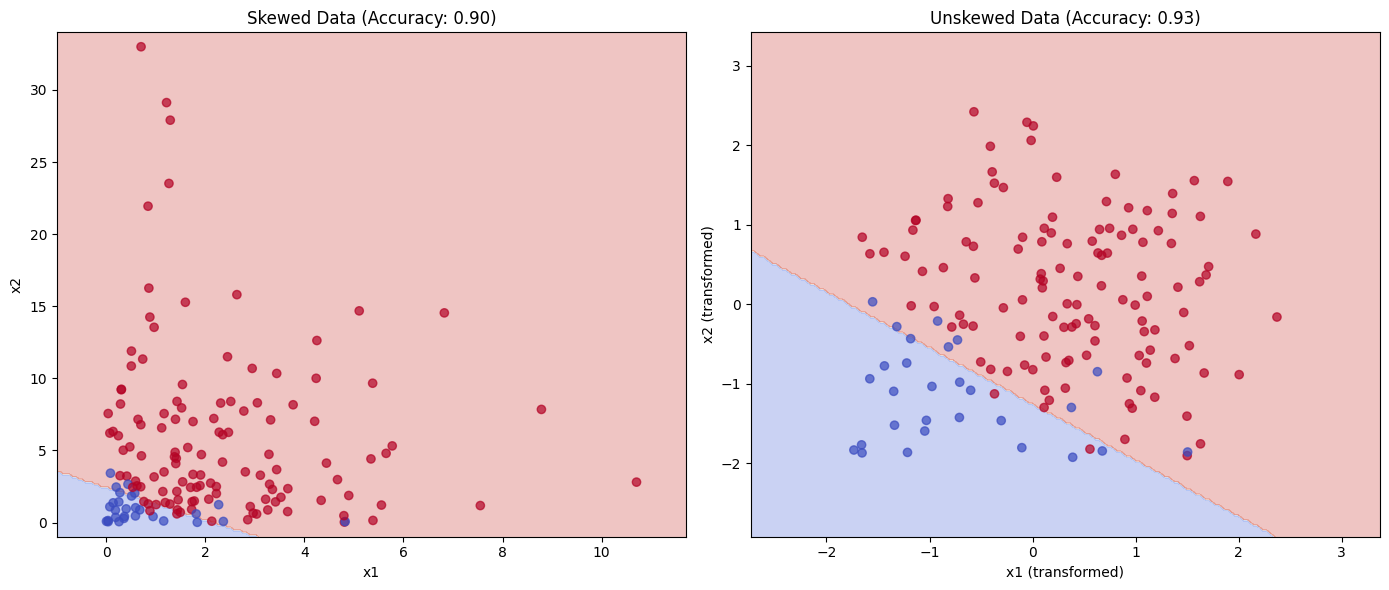

Accuracy without unskewing: 0.90
Accuracy with unskewing: 0.93


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

# Example 2: Logistic regression with skewed features
np.random.seed(10)
n = 500

# Skewed features
x1 = np.random.exponential(scale=2, size=n)
x2 = np.random.exponential(scale=5, size=n)

# Generate binary outcome with a stronger non-linear logistic function
logits = -7 + 5 * np.log(x1 + 1) + 5.0 * np.log(x2 + 1)

probabilities = 1 / (1 + np.exp(-logits))
y_binary = np.random.binomial(1, probabilities)

X = np.column_stack((x1, x2))
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=0)

# Logistic regression without transformation
logreg = LogisticRegression().fit(X_train, y_train)
y_pred = logreg.predict(X_test)
accuracy_raw = accuracy_score(y_test, y_pred)

# Logistic regression with power transformation (unskewing)
pt = PowerTransformer()
X_train_unskewed = pt.fit_transform(X_train)
X_test_unskewed = pt.transform(X_test)

logreg_unskewed = LogisticRegression().fit(X_train_unskewed, y_train)
y_pred_unskewed = logreg_unskewed.predict(X_test_unskewed)
accuracy_unskewed = accuracy_score(y_test, y_pred_unskewed)

# Function to plot decision boundary
def plot_decision_boundary(clf, X, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y_test, cmap='coolwarm', alpha=0.7)
    ax.set_title(title)

# Scatter plot comparison with decision boundaries
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(logreg, X_test, ax[0], f'Skewed Data (Accuracy: {accuracy_raw:.2f})')
ax[0].set_xlabel('x1')
ax[0].set_ylabel('x2')

plot_decision_boundary(logreg_unskewed, X_test_unskewed, ax[1], f'Unskewed Data (Accuracy: {accuracy_unskewed:.2f})')
ax[1].set_xlabel('x1 (transformed)')
ax[1].set_ylabel('x2 (transformed)')

plt.tight_layout()
plt.show()

print(f'Accuracy without unskewing: {accuracy_raw:.2f}')
print(f'Accuracy with unskewing: {accuracy_unskewed:.2f}')


## Key Takeaways and Best Practices

**When to consider unskewing**:
1. **Data exploration**: Always check for skewness in new datasets
2. **Hidden patterns**: Use transformations to reveal obscured structure
3. **Model assumptions**: Transform data to match algorithm assumptions
4. **Performance improvement**: Test if transformations improve model accuracy

**Important considerations**:
- **Don't lose information**: Keep original data for comparison
- **Interpretability**: Transformed results may be harder to interpret
- **Validation**: Always validate that transformations help on test data
- **Domain knowledge**: Some transformations may not make sense for your problem

**Common transformations**:
- **Log transformation**: For exponentially distributed data
- **Power transformations**: For skewed but not exponential data
- **Whitening**: For correlated features
- **Standardization**: For different scales
